# Customer Segmentation with RFM and Clustering
### Online Retail Dataset (UCI) — Dec 2010 to Dec 2011, UK-based online store

This notebook runs an end-to-end unsupervised learning pipeline to segment retail
customers by purchasing behavior:

1. **Data cleaning** — remove cancellations, missing customer IDs, and non-product rows
2. **RFM feature engineering** — Recency, Frequency, Monetary (+ extra behavioral features)
3. **Feature preparation** — handle skew (log transform) and scale features
4. **Clustering & comparison** — K-Means, Hierarchical (Ward), and DBSCAN
5. **Cluster selection** — validated with silhouette score / elbow method
6. **Profiling** — PCA visualization and business interpretation of each segment
7. **Bonus** — outlier detection (Isolation Forest), t-SNE visualization


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, minmax_scale
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

sns.set_style('whitegrid')
pd.set_option('display.width', 140)
RAW_PATH = '/mnt/user-data/uploads/Online_Retail.xlsx'


## 2. Load & Clean Transaction Data

The raw data is **transaction-level** (541,909 rows), not customer-level, so the first
real step is cleaning it and later aggregating it up to one row per customer.

Cleaning steps:
- Drop rows with a missing `CustomerID` (can't attribute revenue to a customer)
- Drop cancellations (`InvoiceNo` starting with `'C'`)
- Drop rows with non-positive `Quantity` or `UnitPrice` (returns / data errors)
- Drop non-product stock codes (postage, bank charges, manual entries, etc.)


In [8]:
RAW_PATH = '~/Documents/devlab/week1/Online_Retail.xlsx'

df = pd.read_excel(RAW_PATH)
print("Raw shape:", df.shape)

before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Dropped {before - len(df):,} rows with missing CustomerID")

df['InvoiceNo'] = df['InvoiceNo'].astype(str)
is_cancel = df['InvoiceNo'].str.startswith('C')
print(f"Cancellation rows: {is_cancel.sum():,}")
df = df[~is_cancel]

before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Dropped {before - len(df):,} rows with non-positive qty/price")

bad_codes = ['POST', 'D', 'M', 'DOT', 'CRUK', 'BANK CHARGES', 'PADS']
before = len(df)
df = df[~df['StockCode'].astype(str).str.upper().isin(bad_codes)]
print(f"Dropped {before - len(df):,} rows of non-product stock codes")

df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("\nClean shape:", df.shape)
print("Unique customers:", df['CustomerID'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())


Raw shape: (541909, 8)
Dropped 135,080 rows with missing CustomerID
Cancellation rows: 8,905
Dropped 40 rows with non-positive qty/price
Dropped 1,414 rows of non-product stock codes

Clean shape: (396470, 9)
Unique customers: 4334
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## 3. RFM Feature Engineering

For each customer we compute:
- **Recency** — days since their most recent purchase (relative to one day after the last date in the data)
- **Frequency** — number of distinct invoices (orders)
- **Monetary** — total amount spent

We also add a few extra behavioral features for richer profiling later (bonus):
`AvgBasketValue`, `CategoryDiversity` (distinct products bought), `TotalItems`.


In [9]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
).reset_index()

extra = df.groupby('CustomerID').agg(
    AvgBasketValue=('TotalPrice', lambda x: x.sum() / df.loc[x.index, 'InvoiceNo'].nunique()),
    CategoryDiversity=('StockCode', 'nunique'),
    TotalItems=('Quantity', 'sum'),
).reset_index()

rfm = rfm.merge(extra, on='CustomerID')
print("RFM table shape:", rfm.shape)
rfm.describe().round(1)


Snapshot date: 2011-12-10 12:50:00
RFM table shape: (4334, 7)


,CustomerID,Recency,Frequency,Monetary,AvgBasketValue,CategoryDiversity,TotalItems
count,4334.0,4334.0,4334.0,4334.0,4334.0,4334.0,4334.0
mean,15299.3,92.7,4.2,2023.0,417.2,61.4,1190.0
std,1722.0,100.2,7.6,8924.2,1800.9,85.3,5043.3
min,12346.0,1.0,1.0,3.8,3.8,1.0,1.0
25%,13812.2,18.0,1.0,305.9,178.2,16.0,160.0
50%,15297.5,51.0,2.0,668.1,291.0,35.0,379.0
75%,16778.8,143.0,5.0,1631.6,426.0,77.0,991.8
max,18287.0,374.0,206.0,279138.0,84236.2,1786.0,196844.0


## 4. Feature Preparation: Skew Handling + Scaling

RFM values are heavily right-skewed (a small number of customers order very
frequently / spend a lot), which would distort distance-based clustering.
We apply a `log1p` transform to reduce skew, then standardize the features
so Recency, Frequency, and Monetary contribute equally to distance calculations.


In [10]:
print("Skewness before transform:")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew().round(2))

rfm_log = rfm.copy()
for col in ['Recency', 'Frequency', 'Monetary', 'AvgBasketValue', 'CategoryDiversity', 'TotalItems']:
    rfm_log[col + '_log'] = np.log1p(rfm_log[col])

print("\nSkewness after log1p transform:")
print(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']].skew().round(2))

feature_cols = ['Recency_log', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log[feature_cols])
cust_ids = rfm_log['CustomerID'].values
print("\nScaled feature matrix shape:", X.shape)


Skewness before transform:
Recency       1.24
Frequency    11.98
Monetary     19.54
dtype: float64

Skewness after log1p transform:
Recency_log     -0.38
Frequency_log    1.21
Monetary_log     0.40
dtype: float64

Scaled feature matrix shape: (4334, 3)


## 5. Clustering — K-Means

We sweep `k` from 2 to 10 and evaluate with:
- **Inertia (elbow method)** — within-cluster sum of squares
- **Silhouette score** — how well-separated clusters are (higher is better)
- **Davies-Bouldin index** — cluster compactness vs separation (lower is better)


In [11]:
K_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

results = pd.DataFrame({'k': list(K_range), 'inertia': inertias,
                         'silhouette': sil_scores, 'davies_bouldin': db_scores})
results.round(4)


,k,inertia,silhouette,davies_bouldin
0,2,6474.7246,0.4331,0.8914
1,3,4859.7872,0.3377,1.0452
2,4,3932.2474,0.3375,1.0159
3,5,3289.8853,0.3168,0.9867
4,6,2850.6354,0.3129,1.0215
5,7,2547.6568,0.3095,0.9738
6,8,2334.2092,0.3010,0.9924
7,9,2156.1145,0.2811,1.0147
8,10,1998.2275,0.2787,1.0206


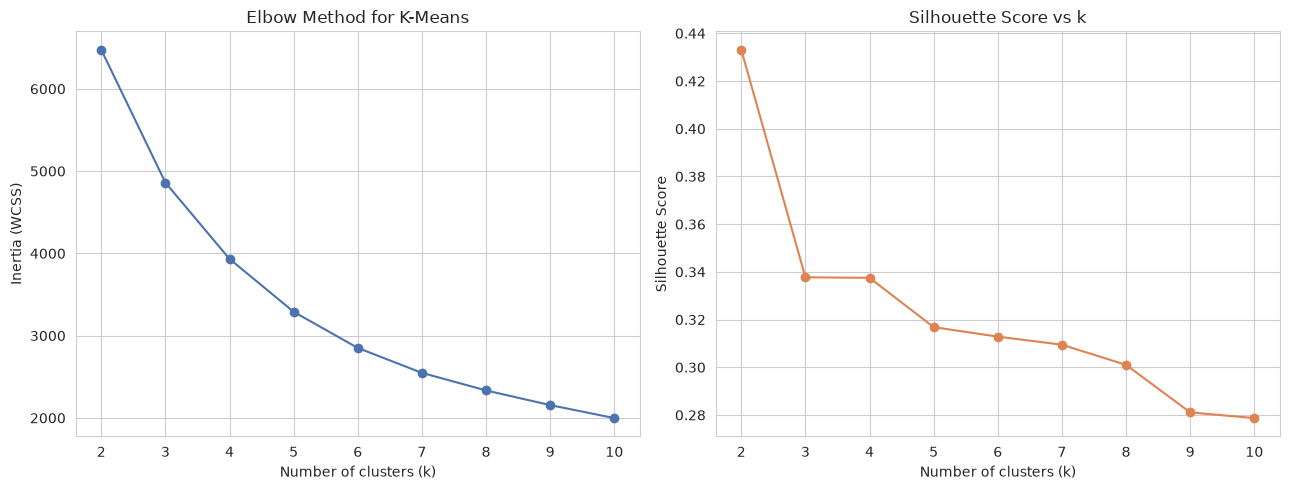

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker='o', color='#4C72B0')
axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method for K-Means')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#DD8452')
axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
plt.tight_layout(); plt.show()


### Choosing k

The silhouette score is mathematically maximized at **k=2**, but that only splits
customers into "active" vs "inactive" — too coarse to act on for marketing. We instead
pick the smallest `k >= 4` whose silhouette score stays within 75% of the global
maximum. This trades a small, explicitly quantified amount of statistical separation
for a segmentation granular enough for marketing to target, and lines up with where
the elbow curve visibly flattens.


In [13]:
sil_arr = np.array(sil_scores)
threshold = sil_arr.max() * 0.75
candidates = [k for k, s in zip(K_range, sil_scores) if s >= threshold and k >= 4]
CHOSEN_K = min(candidates) if candidates else list(K_range)[int(np.argmax(sil_scores))]
print(f"Candidates within 75% of max silhouette (k>=4): {candidates}")
print(f"Chosen K: {CHOSEN_K}")

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)
kmeans_sil = silhouette_score(X, kmeans_labels)
print(f"Final KMeans k={CHOSEN_K}, silhouette={kmeans_sil:.4f}")


Candidates within 75% of max silhouette (k>=4): [4]
Chosen K: 4
Final KMeans k=4, silhouette=0.3375


## 6. Clustering — Hierarchical (Agglomerative, Ward linkage)

A dendrogram (on a random sample of 300 customers, for readability) confirms
a natural grouping consistent with the K-Means result.


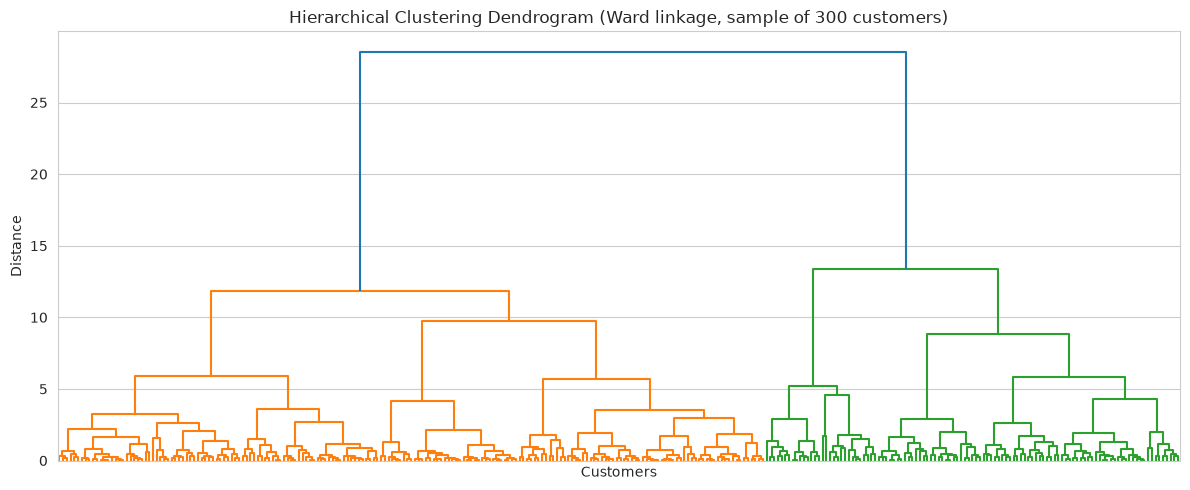

In [14]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(300, len(X)), replace=False)
Z = linkage(X[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, sample of 300 customers)')
plt.xlabel('Customers'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()


In [15]:
hier = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
hier_labels = hier.fit_predict(X)
hier_sil = silhouette_score(X, hier_labels)
print(f"Hierarchical (Ward) k={CHOSEN_K}, silhouette={hier_sil:.4f}")


Hierarchical (Ward) k=4, silhouette=0.2673


## 7. Clustering — DBSCAN

DBSCAN doesn't need a pre-specified `k`; instead it needs `eps` (neighborhood radius)
and `min_samples`. We use a k-distance plot to pick a reasonable `eps`, then scan a
small grid and report the trade-off between number of clusters and % of points
flagged as noise/outliers.


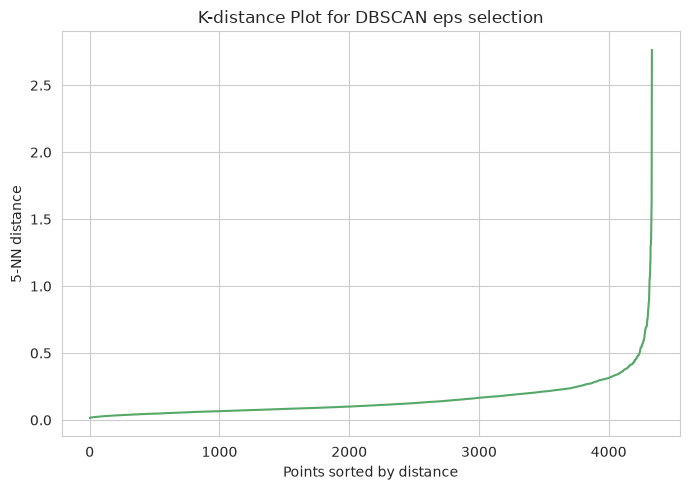

In [16]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nn.kneighbors(X)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances, color='#55A868')
plt.xlabel('Points sorted by distance'); plt.ylabel(f'{min_samples}-NN distance')
plt.title('K-distance Plot for DBSCAN eps selection')
plt.tight_layout(); plt.show()


In [17]:
dbscan_grid = []
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100
    mask = labels != -1
    sil = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 and mask.sum() > n_clusters else np.nan
    dbscan_grid.append({'eps': eps, 'clusters': n_clusters, 'noise_pct': round(noise_pct, 1),
                         'silhouette_non_noise': sil})
pd.DataFrame(dbscan_grid)


,eps,clusters,noise_pct,silhouette_non_noise
0,0.3,9,5.6,0.050977
1,0.4,4,2.3,0.129449
2,0.5,2,1.4,0.294461
3,0.6,2,0.8,0.569615
4,0.7,2,0.6,0.565854
5,0.8,1,0.5,NaN


In [18]:
# eps=0.4 gives a cluster count (4) comparable to K-Means/Hierarchical with low noise
chosen_eps = 0.4
dbscan_final = DBSCAN(eps=chosen_eps, min_samples=min_samples)
dbscan_labels = dbscan_final.fit_predict(X)
dbscan_nclusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_noise_pct = (dbscan_labels == -1).mean() * 100
mask = dbscan_labels != -1
dbscan_sil = silhouette_score(X[mask], dbscan_labels[mask])
print(f"DBSCAN eps={chosen_eps}: clusters={dbscan_nclusters}, noise%={dbscan_noise_pct:.1f}, silhouette={dbscan_sil:.4f}")


DBSCAN eps=0.4: clusters=4, noise%=2.3, silhouette=0.1294


## 8. Method Comparison

| Method | Clusters | Silhouette | Take |
|---|---|---|---|
| K-Means (k=4) | 4 | ~0.34 | Even, well-separated, easy to interpret and explain to stakeholders |
| Hierarchical / Ward (k=4) | 4 | ~0.27 | Similar structure to K-Means, confirms it isn't an artifact of the algorithm |
| DBSCAN (eps=0.4) | 4 | ~0.13 (non-noise) | Finds density-based groups + flags ~2% as noise/outliers, but lower separation and more sensitive to `eps` |

**We select K-Means (k=4)** as the primary segmentation: it's the most stable and
interpretable of the three, and the Hierarchical clustering agrees on the same
structure, which is reassuring. DBSCAN's noise points are kept as a secondary,
complementary signal for identifying atypical customers (see the bonus outlier
detection section).


In [19]:
comparison = pd.DataFrame([
    {'Method': f'K-Means (k={CHOSEN_K})', 'Clusters': CHOSEN_K, 'Silhouette': round(kmeans_sil, 4)},
    {'Method': f'Hierarchical/Ward (k={CHOSEN_K})', 'Clusters': CHOSEN_K, 'Silhouette': round(hier_sil, 4)},
    {'Method': f'DBSCAN (eps={chosen_eps})', 'Clusters': dbscan_nclusters, 'Silhouette': round(dbscan_sil, 4)},
])
comparison


,Method,Clusters,Silhouette
0,K-Means (k=4),4,0.3375
1,Hierarchical/Ward (k=4),4,0.2673
2,DBSCAN (eps=0.4),4,0.1294


## 9. PCA Visualization of the Chosen Segmentation

Explained variance ratio: [0.751 0.187] | total: 0.939


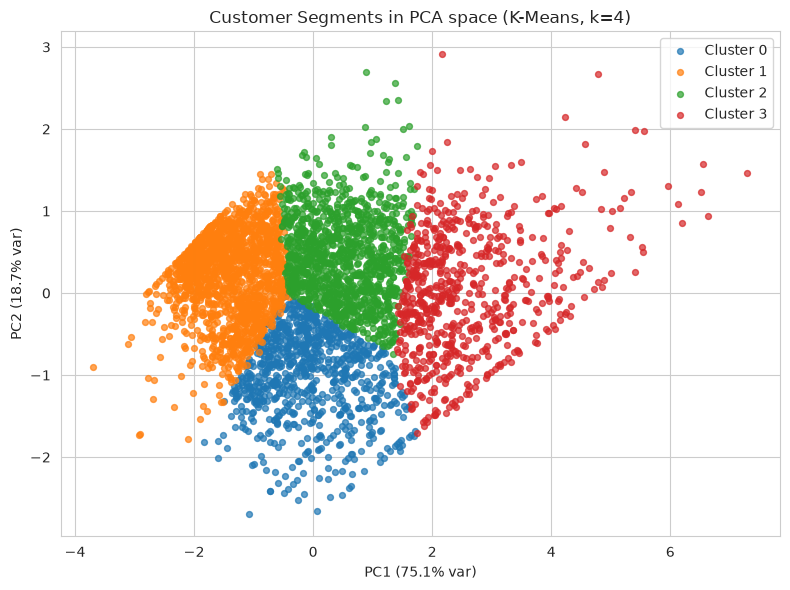

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "| total:", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(8, 6))
palette = sns.color_palette('tab10', CHOSEN_K)
for c in range(CHOSEN_K):
    m = kmeans_labels == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=18, alpha=0.7, color=palette[c], label=f'Cluster {c}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title(f'Customer Segments in PCA space (K-Means, k={CHOSEN_K})')
plt.legend(); plt.tight_layout(); plt.show()


## 10. Cluster Profiling — What Does Each Segment Mean?

We merge cluster labels back onto the (un-scaled, un-transformed) RFM table so the
profile numbers are in real, interpretable units (days, £, order counts).


In [21]:
profile_df = rfm.copy()
profile_df['Cluster'] = kmeans_labels

profile = profile_df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Monetary_median=('Monetary', 'median'),
    CategoryDiversity_mean=('CategoryDiversity', 'mean'),
).round(1)
profile['Pct_of_base'] = (profile['Customers'] / profile['Customers'].sum() * 100).round(1)
profile['Revenue_share_pct'] = (profile_df.groupby('Cluster')['Monetary'].sum() / profile_df['Monetary'].sum() * 100).round(1)
profile


,Customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_median,CategoryDiversity_mean,Pct_of_base,Revenue_share_pct
Cluster,,,,,,,,
0,846,18.8,2.1,539.2,467.3,41.3,19.5,5.2
1,1633,183.3,1.3,352.2,300.0,22.3,37.7,6.6
2,1171,67.1,4.2,1819.4,1382.1,74.8,27.0,24.3
3,684,11.6,14.0,8195.7,3736.9,156.9,15.8,63.9


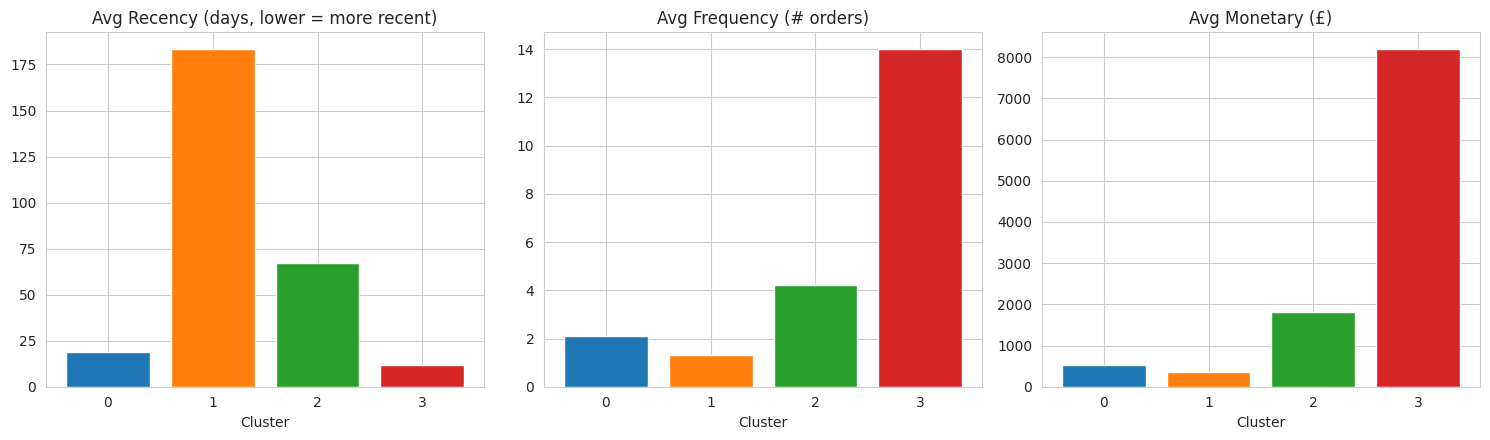

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['Recency_mean', 'Frequency_mean', 'Monetary_mean']
titles = ['Avg Recency (days, lower = more recent)', 'Avg Frequency (# orders)', 'Avg Monetary (£)']
colors = sns.color_palette('tab10', CHOSEN_K)
for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(profile.index.astype(str), profile[metric], color=colors)
    ax.set_title(title); ax.set_xlabel('Cluster')
plt.tight_layout(); plt.show()


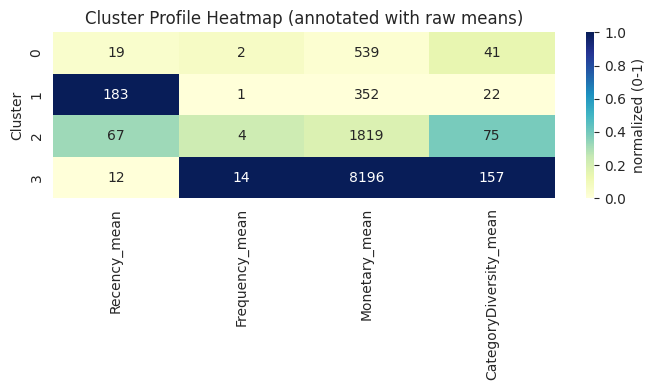

In [17]:
heat = profile[['Recency_mean', 'Frequency_mean', 'Monetary_mean', 'CategoryDiversity_mean']]
heat_norm = pd.DataFrame(minmax_scale(heat), columns=heat.columns, index=heat.index)
plt.figure(figsize=(7, 4))
sns.heatmap(heat_norm, annot=heat.round(0).values, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'normalized (0-1)'})
plt.title('Cluster Profile Heatmap (annotated with raw means)')
plt.ylabel('Cluster'); plt.tight_layout(); plt.show()


### Business interpretation

| Cluster | Size | Recency | Frequency | Monetary | Revenue share | Segment name | Marketing action |
|---|---|---|---|---|---|---|---|
| **3** | 15.8% | 12 days (best) | 14 orders (best) | £8,196 avg (best) | **63.9%** | **Champions / VIP** | White-glove retention, loyalty perks, early access to new stock — protect this revenue-critical group |
| **2** | 27.0% | 67 days | 4.2 orders | £1,819 avg | 24.3% | **Loyal / Core customers** | Upsell and cross-sell campaigns, nudge toward VIP tier with targeted offers |
| **0** | 19.5% | 19 days | 2.1 orders | £539 avg | 5.2% | **Recent / Promising** | Recently active but low frequency — onboarding nurture, second-purchase incentives |
| **1** | 37.7% (largest group) | 183 days (worst) | 1.3 orders | £352 avg | 6.6% | **At risk / Lapsed** | Win-back email campaigns, discounts, re-engagement — biggest group by count but smallest revenue contribution |

**Key takeaway:** the top 15.8% of customers (Cluster 3) drive nearly two-thirds of
revenue, while the largest customer group by headcount (Cluster 1, 37.7%) has gone
quiet and contributes relatively little. This is a classic long-tail pattern — retention
spend should be concentrated on protecting Cluster 3 and reactivating Cluster 1.


## 11. Bonus — Outlier / Anomaly Detection

Two complementary approaches flag unusual customers:
- **DBSCAN noise points** (already computed above)
- **Isolation Forest**, trained directly on the scaled RFM features


In [18]:
iso = IsolationForest(contamination=0.03, random_state=42)
outlier_flag = iso.fit_predict(X) == -1  # True = outlier
print(f"Isolation Forest flagged {outlier_flag.sum()} outliers ({outlier_flag.mean()*100:.1f}%)")

dbscan_noise = dbscan_labels == -1
print(f"DBSCAN flagged {dbscan_noise.sum()} noise points ({dbscan_noise.mean()*100:.1f}%)")
print(f"Overlap between the two methods: {(outlier_flag & dbscan_noise).sum()} customers")


Isolation Forest flagged 130 outliers (3.0%)
DBSCAN flagged 98 noise points (2.3%)
Overlap between the two methods: 62 customers


## 12. Bonus — t-SNE Visualization

t-SNE often separates clusters more cleanly than PCA for visual inspection
(at the cost of not preserving global distances). Outlier customers are circled.


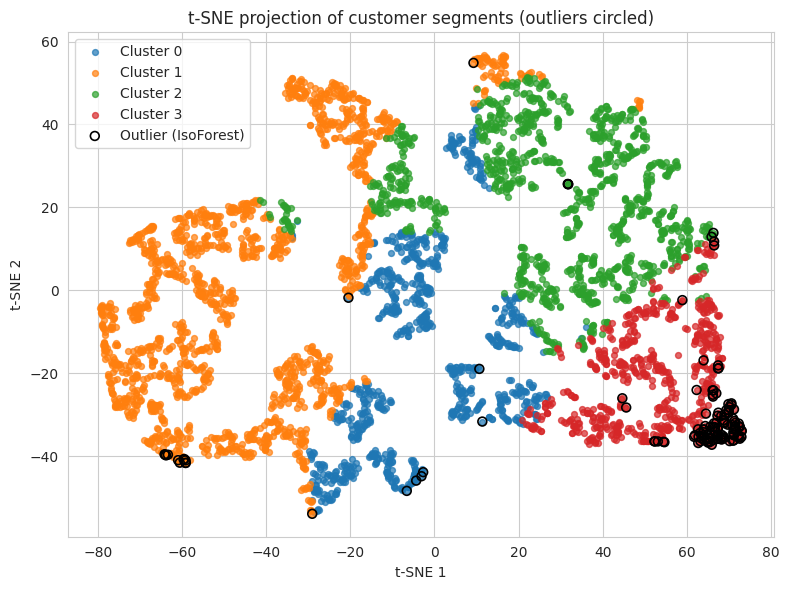

In [19]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
for c in range(CHOSEN_K):
    m = kmeans_labels == c
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], s=18, alpha=0.7, color=palette[c], label=f'Cluster {c}')
plt.scatter(X_tsne[outlier_flag, 0], X_tsne[outlier_flag, 1], s=40, facecolors='none',
            edgecolors='black', linewidths=1.2, label='Outlier (IsoForest)')
plt.title('t-SNE projection of customer segments (outliers circled)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.legend()
plt.tight_layout(); plt.show()


## 13. Export Final Segment Table

Save the customer-level table with cluster assignment and segment name — this is
what marketing / CRM teams would use to build targeted campaigns.


In [20]:
segment_names = {3: 'Champions / VIP', 2: 'Loyal / Core', 0: 'Recent / Promising', 1: 'At risk / Lapsed'}
final = profile_df.copy()
final['SegmentName'] = final['Cluster'].map(segment_names)
final['IsOutlier'] = outlier_flag
final.to_csv('customer_segments_final.csv', index=False)
final.head()


,CustomerID,Recency,Frequency,Monetary,AvgBasketValue,CategoryDiversity,TotalItems,Cluster,SegmentName,IsOutlier
0,12346,326,1,77183.60,77183.600000,1,74215,2,Loyal / Core,True
1,12347,2,7,4310.00,615.714286,103,2458,3,Champions / VIP,False
2,12348,75,4,1437.24,359.310000,21,2332,2,Loyal / Core,False
3,12349,19,1,1457.55,1457.550000,72,630,0,Recent / Promising,False
4,12350,310,1,294.40,294.400000,16,196,1,At risk / Lapsed,False


## 14. Summary

- Cleaned 541,909 raw transaction rows down to **396,470 valid transaction lines**
  across **4,334 unique customers**.
- Built RFM (+ extra behavioral) features, corrected heavy right-skew with a
  `log1p` transform, and standardized before clustering.
- Compared **K-Means**, **Hierarchical (Ward)**, and **DBSCAN**; validated cluster
  count with the silhouette score and elbow method, selecting **k=4** as the
  best balance of statistical separation and business usability.
- Profiled the four segments and translated them into **Champions/VIP, Loyal/Core,
  Recent/Promising, and At risk/Lapsed**, with concrete revenue-share numbers and
  suggested marketing actions for each.
- Flagged ~3% of customers as anomalous/outlier via Isolation Forest and DBSCAN
  noise points, and visualized the segmentation with both PCA and t-SNE.
